In [1]:
import os
import numpy as np
import hyperspy.api as hs

In [2]:
from tifffile import imread, imwrite

In [3]:
import atomap.api as am

/Users/nihy/Desktop/stem_analysis/.venv/lib/python3.14/site-packages/hyperspy/misc/_utils.py:1590: VisibleDeprecationWarning: Importing `LazyComplexSignal1D` from `hyperspy._signals.complex_signal1d` is deprecated and will be removed in the HyperSpy 3.0 release. Import it from `hyperspy.signals` instead.
  warnings.warn(
/Users/nihy/Desktop/stem_analysis/.venv/lib/python3.14/site-packages/hyperspy/misc/_utils.py:1590: VisibleDeprecationWarning: Importing `LazySignal1D` from `hyperspy._signals.signal1d` is deprecated and will be removed in the HyperSpy 3.0 release. Import it from `hyperspy.signals` instead.
  warnings.warn(
/Users/nihy/Desktop/stem_analysis/.venv/lib/python3.14/site-packages/hyperspy/misc/_utils.py:1590: VisibleDeprecationWarning: Importing `LazySignal1D` from `hyperspy._signals.signal1d` is deprecated and will be removed in the HyperSpy 3.0 release. Import it from `hyperspy.signals` instead.
  warnings.warn(


In [4]:
from skimage.filters import gaussian, window

In [5]:
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.colors import Normalize
import seaborn as sns
import colorcet as cc
import stem_analysis.plot as saplot

In [6]:
from stem_analysis import deltaPDF
from skimage.feature import peak_local_max

In [7]:
from matplotlib.widgets import Button, Slider, RangeSlider


In [8]:
#plt.style.use("/Users/nihy/Desktop/stem_analysis/src/stem_analysis/nature.mplstyle")

In [9]:
%matplotlib widget

In [10]:
dx, dy, dz = 0.02630, 0.02630, 1 # in nm

In [11]:
work_dir = '/Users/nihy/Desktop/Working Data/EuAl4/Ptycho/Cryo Zone 100/ds8'

# Load Aligned Image

In [12]:
img_stack = imread(os.path.join(work_dir, "object_phase_cropped_aligned_0_60.tif"))

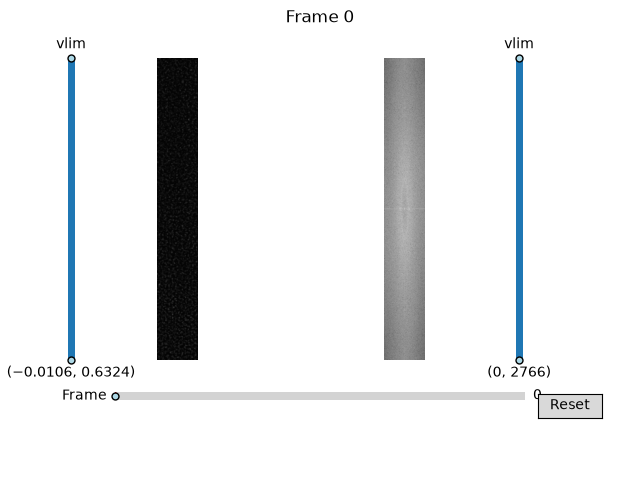

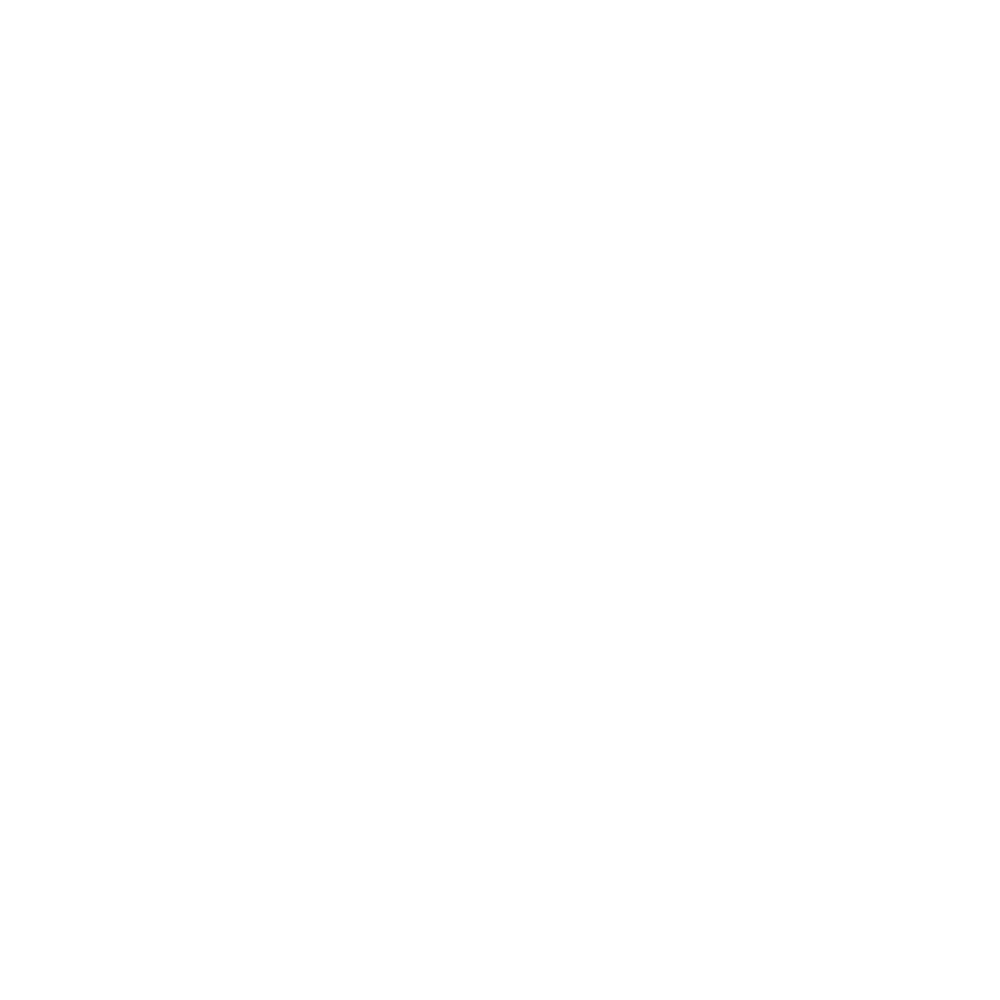

In [13]:
plt.figure(figsize = (10,10))
saplot.SliceViewer(img_stack)

# Show Image

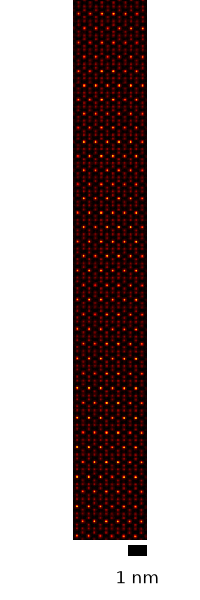

<Axes: >

In [14]:
fig = plt.figure(figsize = (2,6))
saplot.PlotImage(fig,img_stack[10:40].sum(0), dx, cmap = cc.cm.fire ,vmax = img_stack.sum(0).max()*0.7)

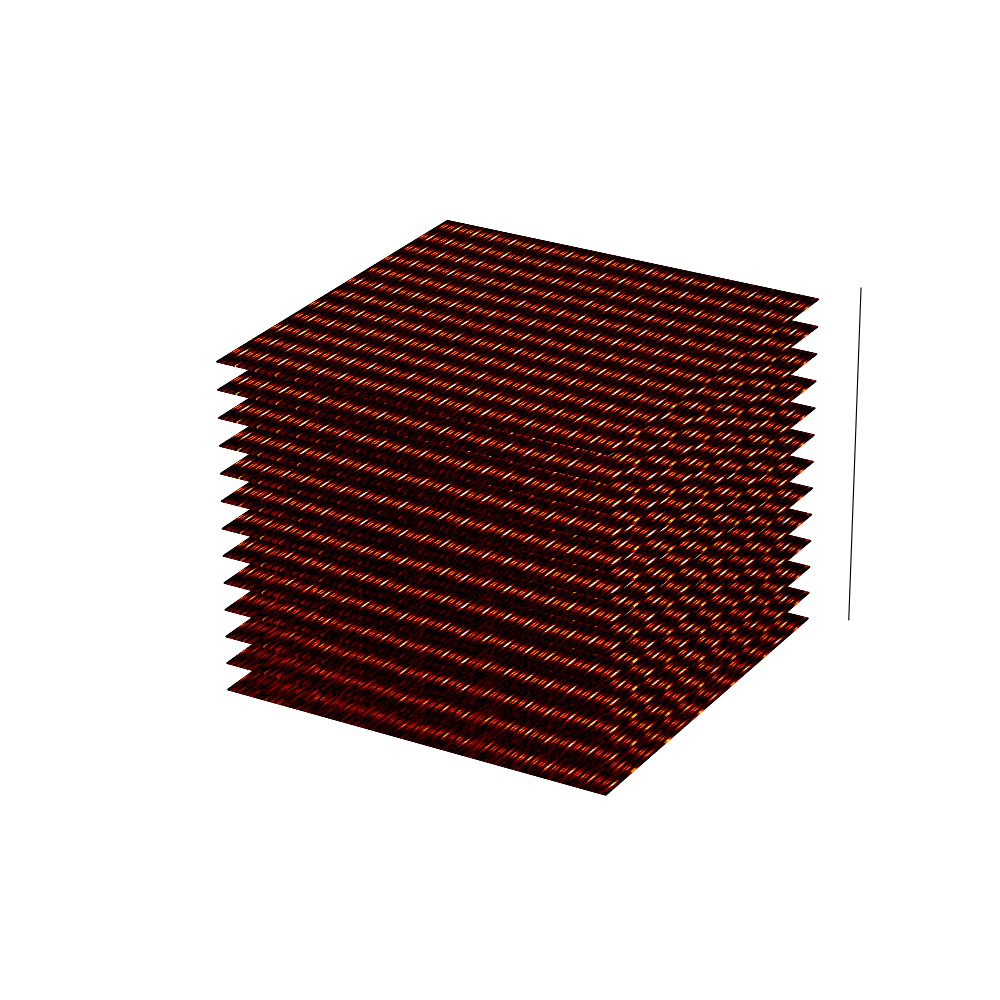

In [110]:

fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(projection='3d')
ax.set(xlabel="x", ylabel="y", zlabel="z")
xi, yi = np.mgrid[0:img_stack.shape[1], 0:img_stack.shape[2]]
norm = Normalize(vmin=0, vmax=np.pi/16)
for i in range(6,19):
    colors = plt.get_cmap(cc.cm.fire)(norm(img_stack[i]))
    ax.plot_surface(xi, yi, np.full_like(xi,i-7), rstride=1, cstride=1, facecolors=colors, shade=False)


ax.xaxis.line.set_visible(False)
ax.set_xticks([])
ax.set_xlabel('')

# Hide lines, ticks, and labels for Y
ax.yaxis.line.set_visible(False)
ax.set_yticks([])
ax.set_ylabel('')

ax.zaxis.line.set_visible(True)
ax.set_zticks([])
ax.set_zlabel('')

ax.view_init(elev=25, azim=-60)
ax.xaxis.pane.set_visible(False)
ax.yaxis.pane.set_visible(False)
ax.zaxis.pane.set_visible(False)  # Hides the floor pane too

#plt.savefig(os.path.join(work_dir, "slice_by_slice.png"), dpi = 300, pad_inches = 0)

In [18]:
nx, ny, nz = 8, 20, 15
data_xy = np.arange(ny * nx).reshape(ny, nx) + 15 * np.random.random((ny, nx))
type(data_xy)

numpy.ndarray

In [19]:
type(img_stack[5])

numpy.ndarray

<>:10: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
<>:10: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
/var/folders/ln/_4p49x493sl51gvfsrdld5640000gn/T/ipykernel_23074/3619102907.py:10: SyntaxWarning: "\p" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\p"? A raw string is also an option.
  cax.set_yticklabels([0, "$\pi$"], fontsize=24)


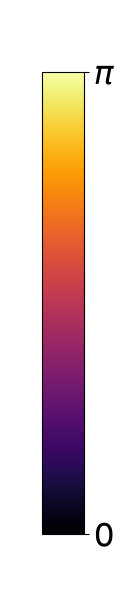

In [20]:
norm = Normalize(vmin=0, vmax=np.pi)
sm = plt.cm.ScalarMappable(norm=norm, cmap="inferno")
sm.set_array([])

fig, cax = plt.subplots(figsize=(1.2, 6))
fig.subplots_adjust(left=0.35, right=0.7)

cbar = fig.colorbar(sm, cax=cax)
cax.set_yticks([0, np.pi])
cax.set_yticklabels([0, "$\pi$"], fontsize=24)

fig.savefig(
    os.path.join(work_dir, "standalone_colorbar.svg"),
    dpi=300,
    bbox_inches="tight",
    transparent=True,
)
plt.show()

In [19]:
dq = 1/(img_stack.shape[1]*dx) # in 1/nm

In [39]:
w = window('hann', img_stack.sum(0).shape)

In [21]:
fft_3d_abs = np.abs(np.fft.fftshift(np.fft.fftn(img_stack[6:19]*w)))
fft_3d_abs.shape

(13, 363, 363)

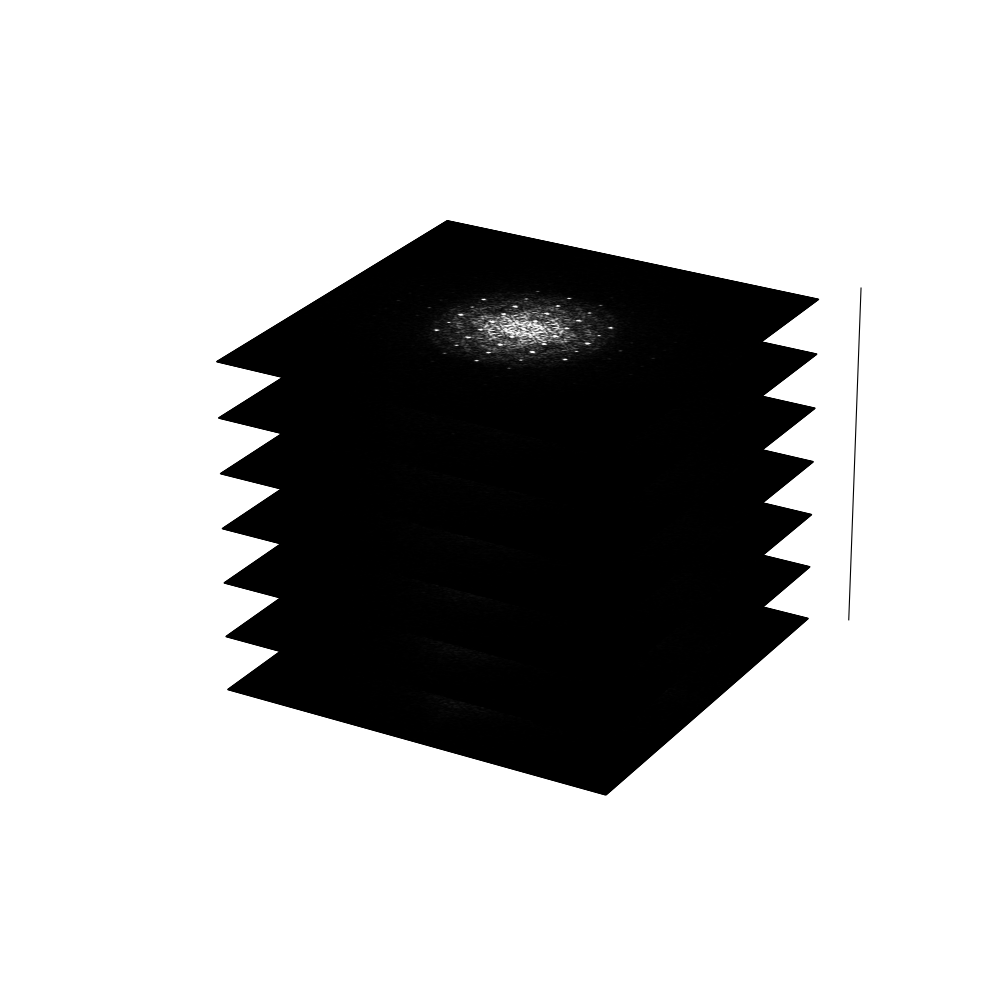

In [22]:

fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(projection='3d')
ax.set(xlabel="x", ylabel="y", zlabel="z")
xi, yi = np.mgrid[0:img_stack.shape[1], 0:img_stack.shape[2]]
norm = Normalize(vmin=0, vmax=200)
for i in range(0,13//2+1):
    colors = plt.get_cmap('gray')(norm(fft_3d_abs[i]))
    ax.plot_surface(xi, yi, np.full_like(xi,i), rstride=1, cstride=1, facecolors=colors, shade=False)


ax.xaxis.line.set_visible(False)
ax.set_xticks([])
ax.set_xlabel('')

# Hide lines, ticks, and labels for Y
ax.yaxis.line.set_visible(False)
ax.set_yticks([])
ax.set_ylabel('')

ax.zaxis.line.set_visible(True)
ax.set_zticks([])
ax.set_zlabel('')

ax.view_init(elev=25, azim=-60)
ax.xaxis.pane.set_visible(False)
ax.yaxis.pane.set_visible(False)
ax.zaxis.pane.set_visible(False)  # Hides the floor pane too

plt.savefig(os.path.join(work_dir, "fft_slice_by_slice.png"), dpi = 300, pad_inches = 0)

In [23]:
imwrite(os.path.join(work_dir, "fft_3d_abs.tif"), fft_3d_abs)

In [24]:
fft_sump_abs = np.abs(np.fft.fftshift(np.fft.fftn(img_stack[6:19].sum(0)*w)))
fft_sump_abs.shape

(363, 363)

In [25]:
saplot.PlotDiff(gaussian(fft_3d_abs[13//2+0],1.0), dq, norm = 'linear', cmap = 'gray', vmax_percentile = 99.5)
plt.savefig(os.path.join(work_dir, "fft_3d_abs_smooth_kz_0.svg"), dpi = 300, pad_inches = 0, transparent = True)

TypeError: PlotDiff() missing 1 required positional argument: 'dq'

(np.float64(-0.5), np.float64(362.5), np.float64(362.5), np.float64(-0.5))

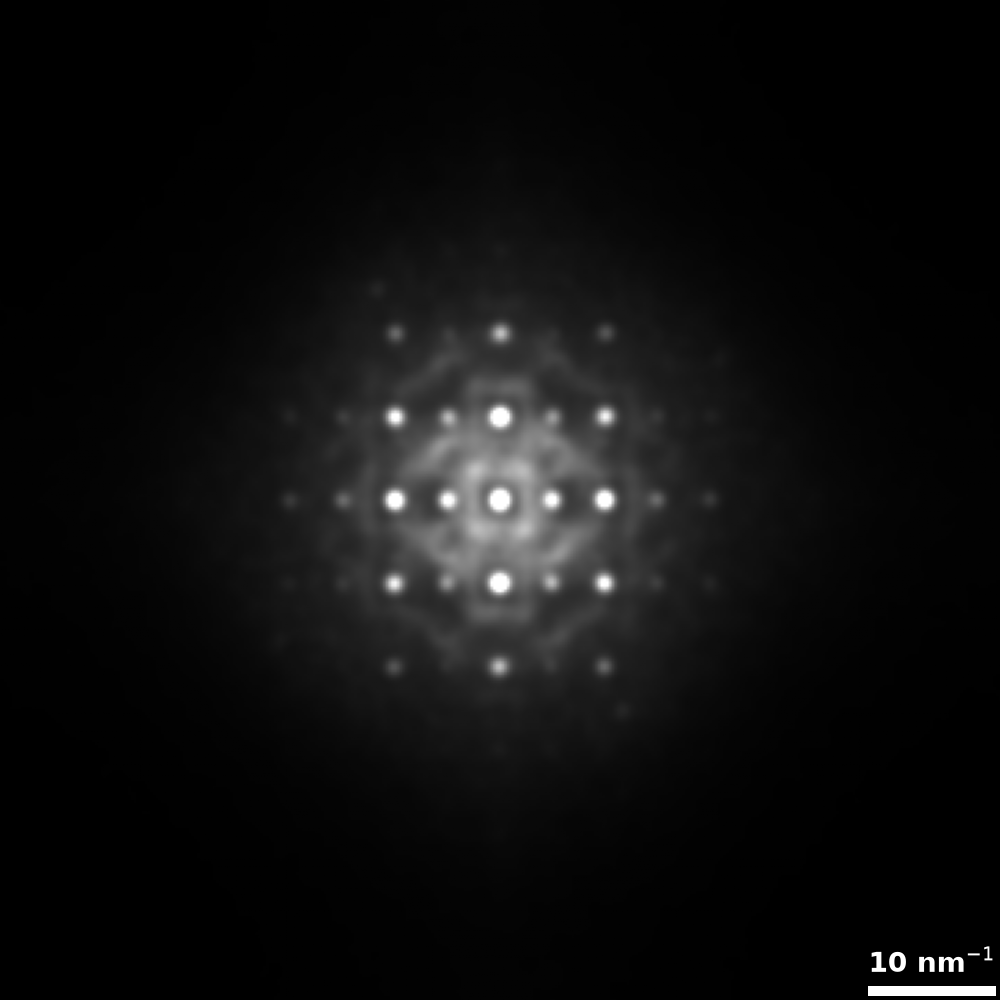

In [26]:
plt.figure(figsize = (10,10))
plt.subplots_adjust(0, 0, 1, 1)
plt.imshow(gaussian(fft_3d_abs.sum(0),2.0), cmap='gray', vmax = 1000)
ax = plt.gca()
sbar = ScaleBar(
    dq,
    '1/nm',
    dimension = "si-length-reciprocal",
    location = 'lower right',
    fixed_value = 10,
    frameon = False,
    color = 'w',
    scale_loc = 'top',
    font_properties = {'size': 20, 'weight': 'bold'}
)
ax.add_artist(sbar)
ax.axis("off")
#plt.savefig(os.path.join(work_dir, "ptyrad_fft_aligned_sum_z.svg"), dpi = 300, bbox_inches = 'tight', pad_inches = 0)

NameError: name 'pseudoDP' is not defined

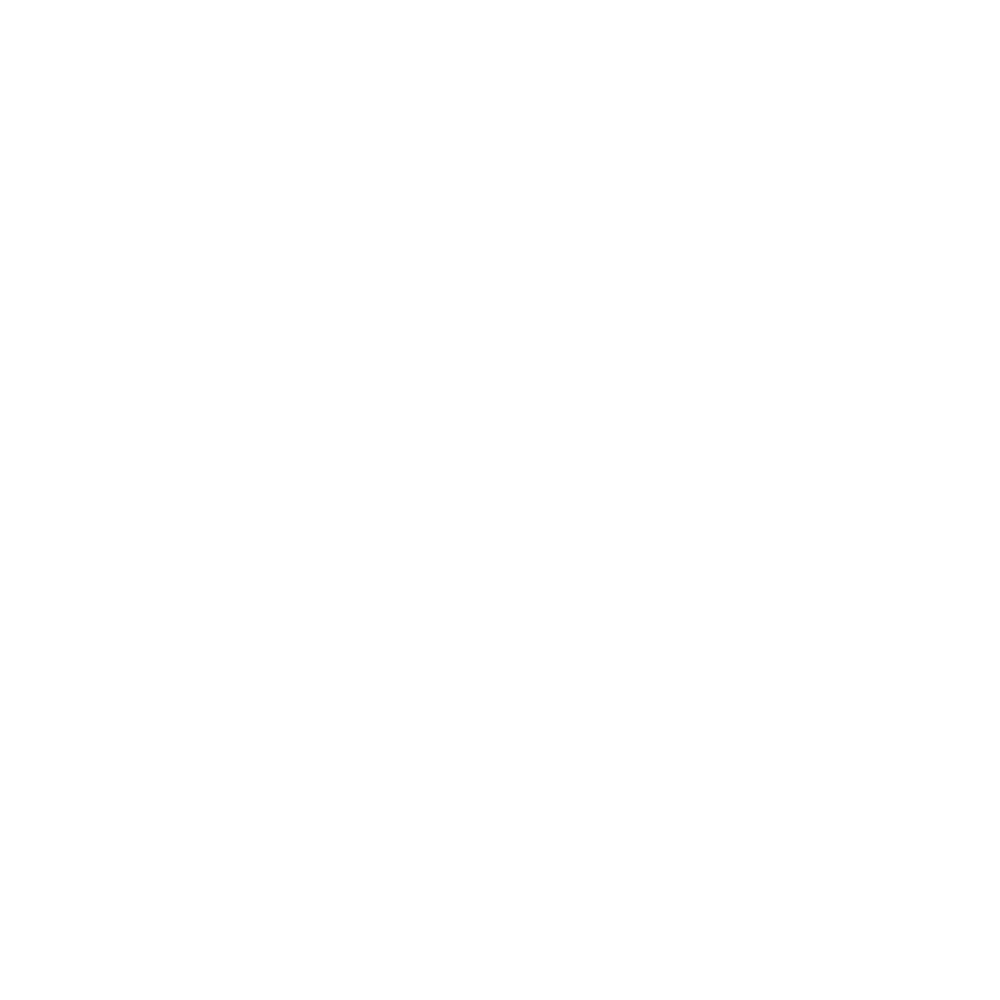

In [27]:
plt.figure(figsize = (10,10))
plt.subplots_adjust(0, 0, 1, 1)
plt.imshow(pseudoDP, cmap='gray', vmax = 1000)
plt.scatter(peaks[:,1], peaks[:,0])
ax = plt.gca()
sbar = ScaleBar(
    dq,
    '1/nm',
    dimension = "si-length-reciprocal",
    location = 'lower right',
    fixed_value = 10,
    frameon = False,
    color = 'w',
    scale_loc = 'top',
    font_properties = {'size': 20, 'weight': 'bold'}
)
ax.add_artist(sbar)
ax.axis("off")
#plt.savefig(os.path.join(work_dir, "ptyrad_fft_aligned_sum_z.svg"), dpi = 300, bbox_inches = 'tight', pad_inches = 0)

In [28]:
pseudoDP = gaussian(fft_3d_abs[13//2],1.5)
peaks = peak_local_max(pseudoDP, min_distance = 14, threshold_abs = 50)

(np.float64(-0.5), np.float64(362.5), np.float64(362.5), np.float64(-0.5))

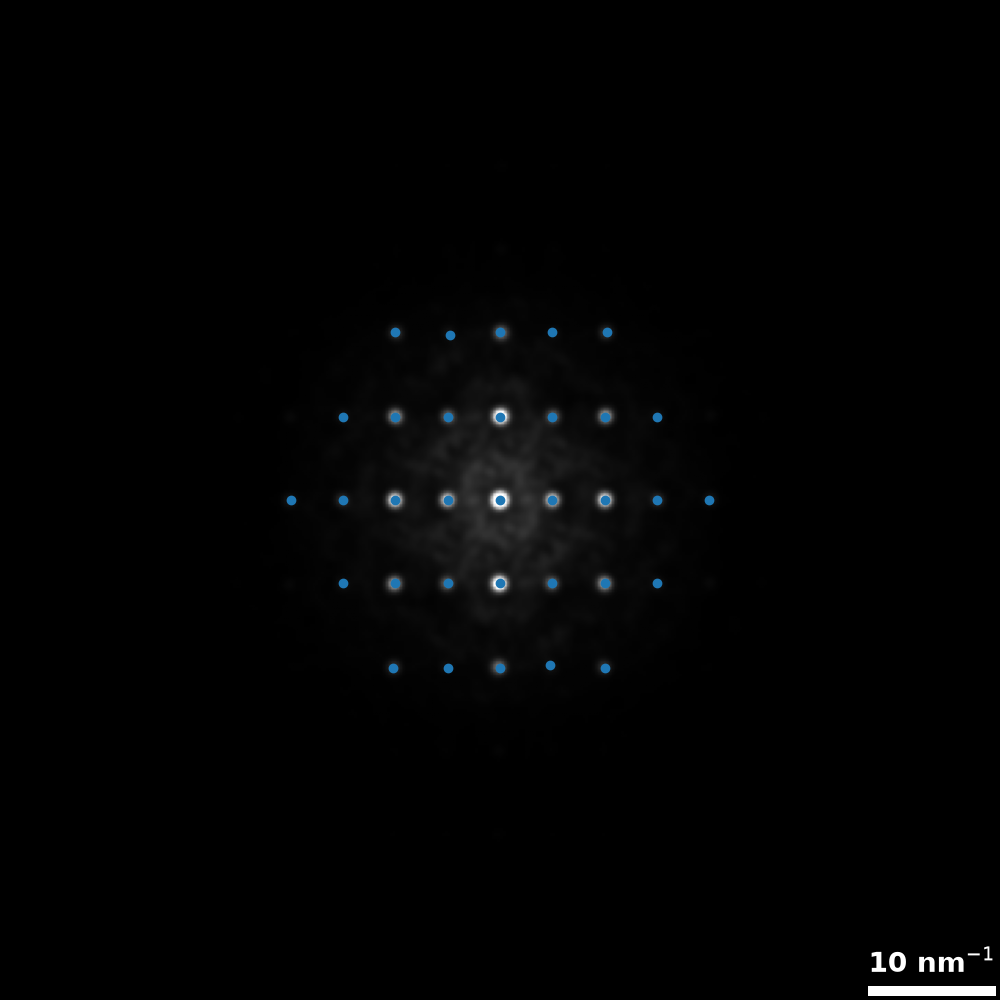

In [29]:
plt.figure(figsize = (10,10))
plt.subplots_adjust(0, 0, 1, 1)
plt.imshow(pseudoDP, cmap='gray', vmax = 1000)
plt.scatter(peaks[:,1], peaks[:,0])
ax = plt.gca()
sbar = ScaleBar(
    dq,
    '1/nm',
    dimension = "si-length-reciprocal",
    location = 'lower right',
    fixed_value = 10,
    frameon = False,
    color = 'w',
    scale_loc = 'top',
    font_properties = {'size': 20, 'weight': 'bold'}
)
ax.add_artist(sbar)
ax.axis("off")
#plt.savefig(os.path.join(work_dir, "ptyrad_fft_aligned_sum_z.svg"), dpi = 300, bbox_inches = 'tight', pad_inches = 0)

In [30]:
pseudoDP = gaussian(fft_3d_abs[13//2+1],1.5)
punched = deltaPDF.PunchAndFill(pseudoDP, peaks, 6)

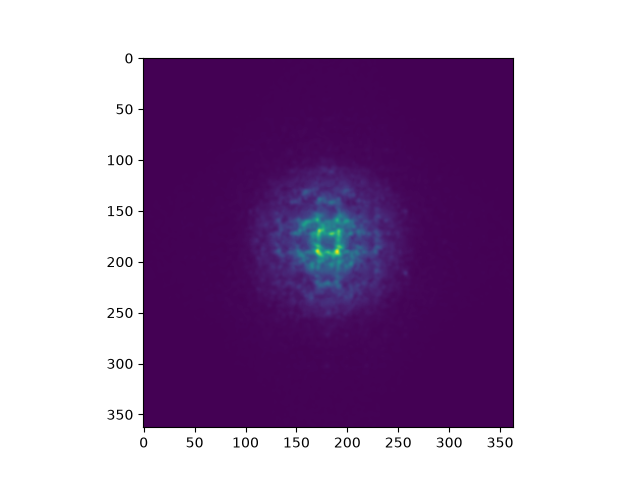

In [31]:
plt.figure()
plt.imshow(punched)

In [32]:
dPDF = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(punched*w))).real

In [33]:
h_lattices = 11.97*np.arange(-10, 11) + punched.shape[0]//2
v_lattices = 19.08*np.arange(-10, 11) + punched.shape[0]//2

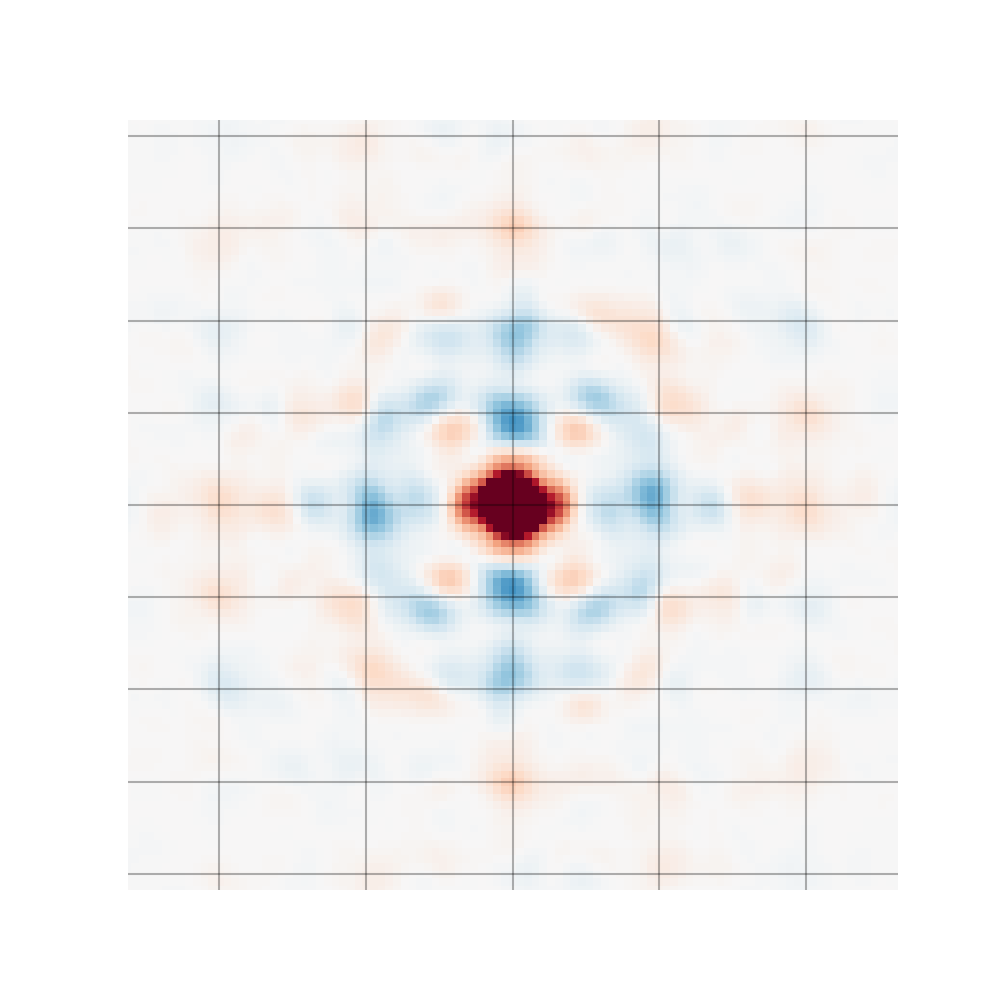

In [34]:
plt.figure(figsize = (10, 10))
plt.imshow(dPDF, cmap = 'RdBu_r', vmax = 6e4, vmin = -6e4)
plt.hlines(h_lattices, 0, punched.shape[0], colors = 'k', alpha = 0.3)
plt.vlines(v_lattices, 0, punched.shape[0], colors = 'k', alpha = 0.3)
plt.xlim(punched.shape[0]//2 - 50 , punched.shape[0]//2 + 50)
plt.ylim(punched.shape[1]//2 - 50 , punched.shape[1]//2 + 50)
plt.axis("off")
plt.savefig(os.path.join(work_dir, "deltaPDF_kz_1.svg"), dpi = 300, pad_inches = 0, transparent = True, bbox_inches = 'tight')

# Fit atomic columns of Sum Phase Image

In [21]:
# Use previously calculated sublattice positions
sublattices = am.load_atom_lattice_from_hdf5(os.path.join(work_dir, "sum_phase_lattice.hdf5"))
A_sublattice = sublattices.sublattice_list[0]
B_sublattice = sublattices.sublattice_list[1]

Image data has negative values, with the lowest being -0.07313139736652374. This is not supported, and can lead to bad fitting results. To fix the negative values, by increasing all pixel values by -0.07313139736652374, use the fix_negative_values=True parameter


IndexError: list index out of range

In [15]:
summed_phase = hs.signals.Signal2D(img_stack[10:40].sum(0))

In [16]:
s_peaks = am.get_feature_separation(summed_phase, separation_range=(2, 20), show_progressbar=False)
s_peaks.plot()


In [17]:
atom_positions = am.get_atom_positions(summed_phase, separation= 10)

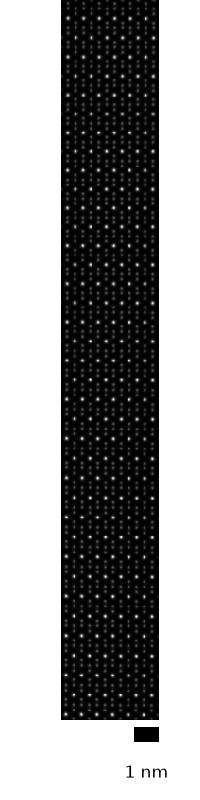

In [18]:
fig = plt.figure(figsize = (2,8))
ax = saplot.PlotImage(fig, summed_phase.data, dx)
ax.scatter(atom_positions[:,0], atom_positions[:,1], s = 6)

In [19]:
sublattice_A = am.Sublattice(atom_positions, image=summed_phase.data)
sublattice_A.construct_zone_axes()
#sublattice_A.find_nearest_neighbors()
sublattice_A.refine_atom_positions_using_center_of_mass()
sublattice_A.refine_atom_positions_using_2d_gaussian()
sublattice_A.construct_zone_axes()


Image data has negative values, with the lowest being -0.062253598123788834. This is not supported, and can lead to bad fitting results. To fix the negative values, by increasing all pixel values by -0.062253598123788834, use the fix_negative_values=True parameter
Gaussian fitting: 100%|██████████| 180/180 [00:00<00:00, 318.66it/s]


In [33]:
from atomap.tools import remove_atoms_from_image_using_2d_gaussian


In [34]:
image_without_A = remove_atoms_from_image_using_2d_gaussian(sublattice_A.image, sublattice_A)

Image data has negative values, with the lowest being -0.062253598123788834. This is not supported, and can lead to bad fitting results. To fix the negative values, by increasing all pixel values by -0.062253598123788834, use the fix_negative_values=True parameter
100%|██████████| 180/180 [00:00<00:00, 54116.17it/s]


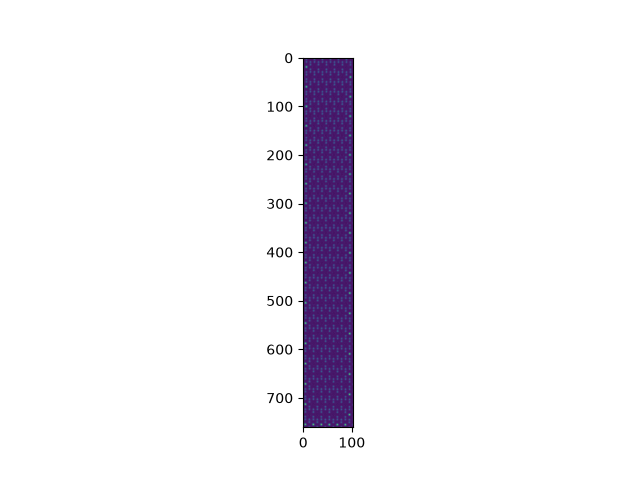

In [35]:
plt.figure()
plt.imshow(image_without_A)

In [37]:
imwrite(os.path.join(work_dir, 'image_without_A.tif'), image_without_A)

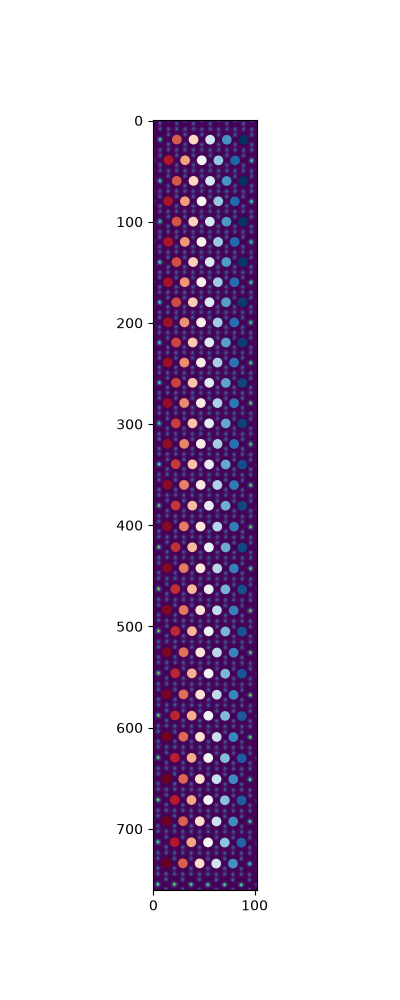

In [32]:
plt.figure(figsize = (4, 10))
plt.imshow(summed_phase)
plt.scatter(coords_sorted[:, 0], coords_sorted[:, 1], c = np.arange(len(coords_sorted)), marker='o', linestyle='None', cmap = 'RdBu')

In [23]:
groups = []
current_group = [coords_sorted[0]]

for point in coords_sorted[1:]:
    if abs(point[0] - current_group[-1][0]) <= 2:
        current_group.append(point)
    else:
        groups.append(np.array(current_group))
        current_group = [point]

groups.append(np.array(current_group))

In [28]:
groups[0].sort()

In [29]:
groups[0]

array([[ 12.6791578 , 734.00427271],
       [ 12.79422697, 692.24084284],
       [ 12.93023247, 650.51260674],
       [ 13.05443425, 608.81014566],
       [ 13.17243625, 567.0508891 ],
       [ 13.30766983, 525.3775716 ],
       [ 13.3784959 , 483.70925504],
       [ 13.51233605, 442.2119289 ],
       [ 13.61734354, 401.02692908],
       [ 13.76111861, 359.99254829],
       [ 13.90452352, 319.48990752],
       [ 14.01704864, 279.17763801],
       [ 14.13923602, 239.19876127],
       [ 14.26597684, 199.50744621],
       [ 14.43616496, 159.73735931],
       [ 14.64291314,  79.75684515],
       [ 14.64806861, 120.01632473],
       [ 14.91951841,  39.13050392]])

In [25]:
coeff = np.polyfit(groups[5][:, 1], groups[5][:, 0], 1)
p = np.poly1d(coeff)

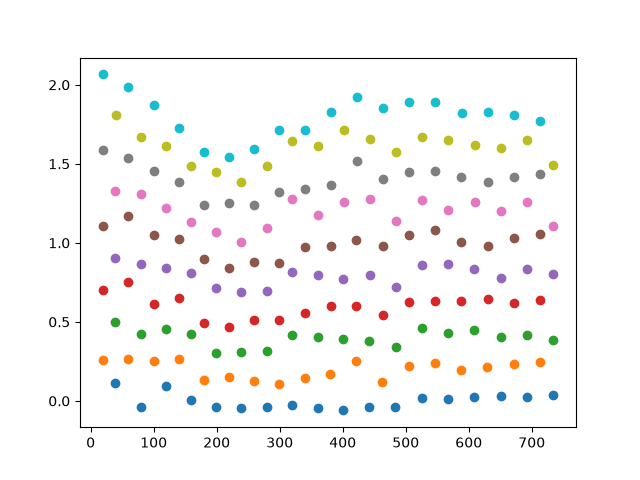

In [30]:
plt.figure()
for i in range(len(groups)):
    coeff = np.polyfit(groups[i][:, 1], groups[i][:, 0], 1)
    p = np.poly1d(coeff)
    plt.plot(groups[i][:, 1], groups[i][:, 0] - p(groups[i][:, 1])+0.2*i, 'o')
#plt.plot(groups[5][:, 1], groups[5][:, 0], 'o-')
#plt.plot(groups[5][:, 1], p(groups[5][:, 1]), 'r--')
#ax = plt.gca()
#ax1 = ax.twinx()
#ax1.plot(groups[5][:, 1], groups[5][:, 0]-p(groups[5][:, 1]), 'g--')

In [46]:
atom_lattice.save(os.path.join(work_dir, "atom_lattice_summed_phase_aligned.hdf5"), overwrite=True)

In [49]:
s_peaks = am.get_feature_separation(hs.signals.Signal2D(image_without_A), separation_range=(2, 20), show_progressbar=False)
s_peaks.plot()

In [73]:
s = hs.signals.Signal2D(image_without_A[10:-10,10:-10])

In [83]:
atom_positions = am.get_atom_positions(s, separation=2, threshold_rel = 0.2)

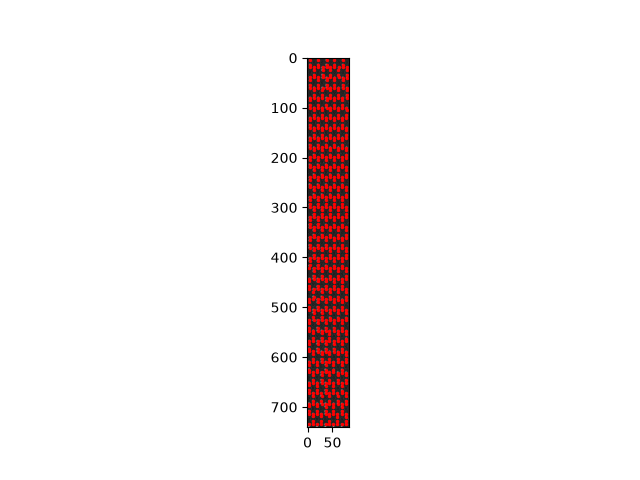

In [84]:
plt.figure()
plt.imshow(s, cmap='gray')
plt.scatter(atom_positions[:, 0], atom_positions[:, 1], s=2, c='red')

In [87]:
s_peaks = am.get_feature_separation(s, separation_range=(3, 20), show_progressbar=False)
s_peaks.plot()

In [85]:
import atomap.initial_position_finding as ipf
dumbbell_vector = ipf.find_dumbbell_vector(atom_positions)

In [95]:
dumbbell_positions = am.get_atom_positions(s, separation=7, threshold_rel=0.2)


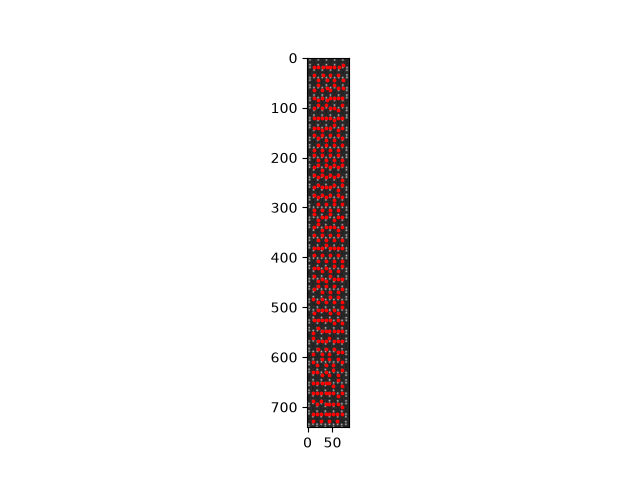

In [96]:
plt.figure()
plt.imshow(s, cmap='gray')
plt.scatter(dumbbell_positions[:, 0], dumbbell_positions[:, 1], s=3, c='red')

Finding dumbbells: 100%|██████████| 297/297 [00:00<00:00, 4654.89it/s]


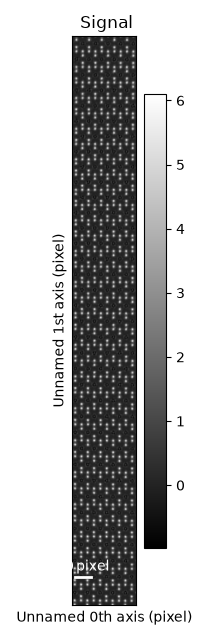

In [89]:
dumbbell_lattice = ipf.make_atom_lattice_dumbbell_structure(s, dumbbell_positions, dumbbell_vector)
dumbbell_lattice.plot()

# Fit Sublattice layer-by-layer

In [47]:
am.load_atom_lattice_from_hdf5(os.path.join(work_dir, "atom_lattice_summed_phase_aligned.hdf5"))
sublattice_A = atom_lattice.sublattice_list[0]
sublattice_B = atom_lattice.sublattice_list[1]

In [48]:
A_position = sublattice_A.atom_positions
B_position = sublattice_B.atom_positions

In [49]:
z_top, z_bottom = 8, 17+1

In [50]:
A_sublattices_by_slice = []
for i in range(z_top, z_bottom):
    summed_phase_slice = hs.signals.Signal2D(img_stack[i])
    sublattice_A_slice = am.Sublattice(A_position, image=summed_phase_slice.data)
    sublattice_A_slice.find_nearest_neighbors()
    sublattice_A_slice.refine_atom_positions_using_center_of_mass()
    sublattice_A_slice.refine_atom_positions_using_2d_gaussian()
    A_sublattices_by_slice.append(sublattice_A_slice)

Gaussian fitting: 100%|██████████| 522/522 [00:01<00:00, 326.93it/s]


In [51]:
B_sublattices_by_slice = []
for i in range(z_top, z_bottom):
    summed_phase_slice = hs.signals.Signal2D(img_stack[i])
    sublattice_B_slice = am.Sublattice(B_position, image=summed_phase_slice.data)
    sublattice_B_slice.find_nearest_neighbors()
    sublattice_B_slice.refine_atom_positions_using_center_of_mass()
    sublattice_B_slice.refine_atom_positions_using_2d_gaussian()
    B_sublattices_by_slice.append(sublattice_B_slice)

Gaussian fitting:  27%|██▋       | 143/522 [00:00<00:01, 356.90it/s]

WARNING | Hyperspy | Covariance of the parameters could not be estimated. Estimated parameter standard deviations will be np.nan. (hyperspy.model:1753)
WARNING | Hyperspy | `m.fit()` did not exit successfully. Reason: Number of calls to function has reached maxfev = 1400. (hyperspy.model:2388)
WARNING | Hyperspy | Covariance of the parameters could not be estimated. Estimated parameter standard deviations will be np.nan. (hyperspy.model:1753)
WARNING | Hyperspy | `m.fit()` did not exit successfully. Reason: Number of calls to function has reached maxfev = 1400. (hyperspy.model:2388)
WARNING | Hyperspy | Covariance of the parameters could not be estimated. Estimated parameter standard deviations will be np.nan. (hyperspy.model:1753)
WARNING | Hyperspy | `m.fit()` did not exit successfully. Reason: Number of calls to function has reached maxfev = 1400. (hyperspy.model:2388)
WARNING | Hyperspy | Covariance of the parameters could not be estimated. Estimated parameter standard deviations w

Gaussian fitting: 100%|██████████| 522/522 [00:01<00:00, 295.54it/s]


100%|██████████| 522/522 [00:00<00:00, 45825.00it/s]


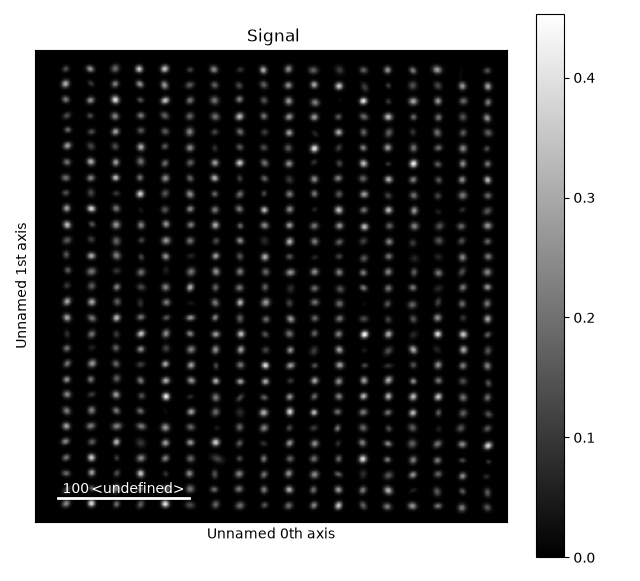

In [52]:
A_sublattices_by_slice[5].get_model_image().plot()

In [53]:
w.shape

(363, 363)

In [54]:
B_model_img = np.sum([B_sublattices_by_slice[i].get_model_image().data for i in range(len(B_sublattices_by_slice))], axis=0)
B_model_img_fft = np.fft.fftshift(np.fft.fft2(B_model_img*w))

100%|██████████| 522/522 [00:00<00:00, 51549.88it/s]


/var/folders/ln/_4p49x493sl51gvfsrdld5640000gn/T/ipykernel_61145/3173213996.py:1: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


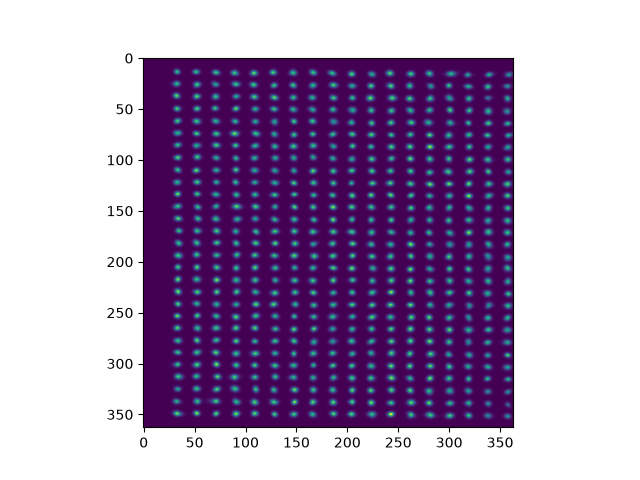

In [55]:
plt.figure()
plt.imshow(B_model_img)

In [56]:
A_model_img = np.sum([A_sublattices_by_slice[i].get_model_image().data for i in range(len(A_sublattices_by_slice))], axis=0)
A_model_img_fft = np.fft.fftshift(np.fft.fft2(A_model_img*w))

100%|██████████| 522/522 [00:00<00:00, 53243.52it/s]


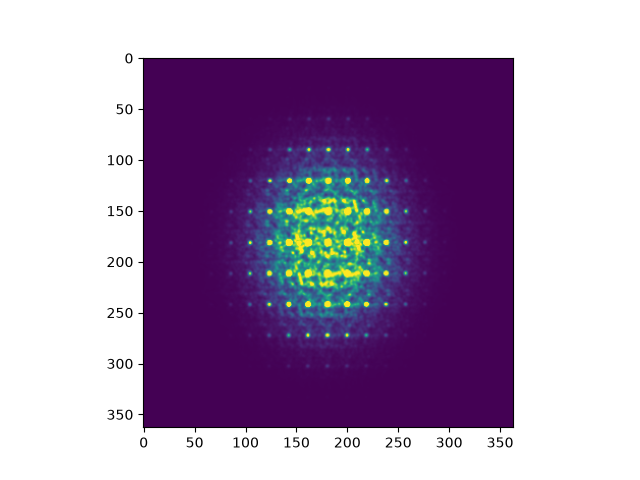

In [57]:
plt.figure()
plt.imshow(gaussian(np.abs(B_model_img_fft),1),vmax = 30)

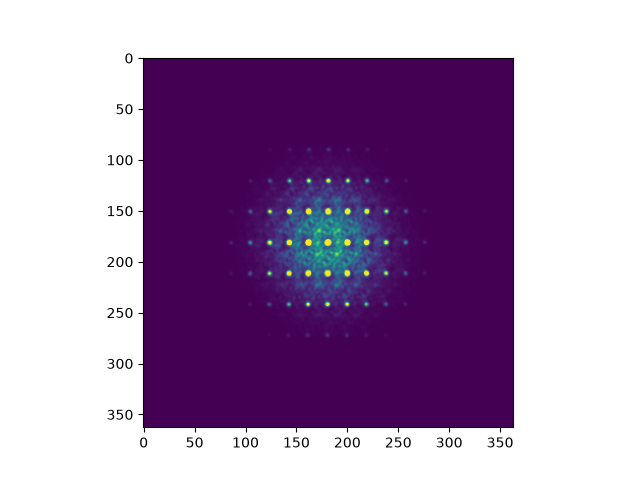

In [58]:
plt.figure()
plt.imshow(gaussian(np.abs(A_model_img_fft),1), vmax = 200, vmin = 1)

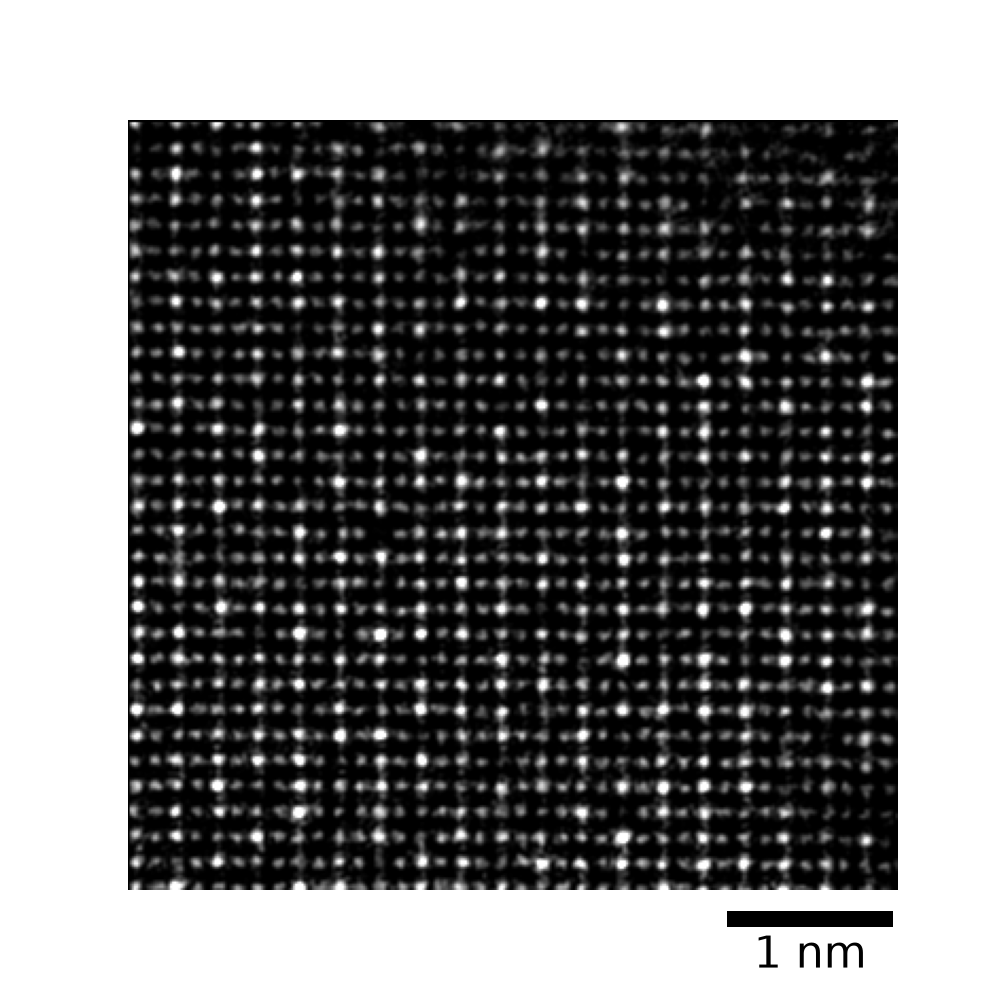

In [59]:
saplot.PlotImage(img_stack[z_bottom-1], dx)
plt.scatter(A_sublattices_by_slice[-1].atom_positions[:,0], A_sublattices_by_slice[-1].atom_positions[:,1])
plt.scatter(B_sublattices_by_slice[-1].atom_positions[:,0], B_sublattices_by_slice[-1].atom_positions[:,1])

# Calculate $\Delta xy$ for A and B sublattices

In [ ]:
A_delta_pos = []
for sublattice in A_sublattices_by_slice:
    delta_pos = sublattice.atom_positions - A_position
    A_delta_pos.append(delta_pos)
A_delta_pos = np.swapaxes(np.array(A_delta_pos), 0, 1)
A_delta_pos.shape

In [ ]:
B_delta_pos = []
for sublattice in B_sublattices_by_slice:
    delta_pos = sublattice.atom_positions - B_position
    B_delta_pos.append(delta_pos)
B_delta_pos = np.swapaxes(np.array(B_delta_pos), 0, 1)
B_delta_pos.shape

In [ ]:
ind = np.random.randint(len(A_delta_pos))
plt.figure()
plt.plot(A_delta_pos[ind, :, 0], marker="o", label="Delta x")
plt.plot(A_delta_pos[ind, :, 1], marker="o", label="Delta y")

In [ ]:
ind = np.random.randint(len(B_delta_pos))
plt.figure()
plt.plot(B_delta_pos[ind, :, 0], marker="o", label="Delta x")
plt.plot(B_delta_pos[ind, :, 1], marker="o", label="Delta y")

In [ ]:
_, axs = plt.subplots(1, 2, figsize=(6,12))
for i in range(len(A_delta_pos)):
    axs[0].plot(A_delta_pos[i][:, 0], alpha=0.2, color = 'gray')
    axs[1].plot(A_delta_pos[i][:, 1], alpha=0.2, color = 'gray')
axs[0].plot(np.mean(A_delta_pos,0)[...,0])
axs[1].plot(np.mean(A_delta_pos,0)[...,1])

In [ ]:
_, axs = plt.subplots(1, 2, figsize=(6,12))
for i in range(len(B_delta_pos)):
    axs[0].plot(B_delta_pos[i][:, 0], alpha=0.2, color = 'gray')
    axs[1].plot(B_delta_pos[i][:, 1], alpha=0.2, color = 'gray')
axs[0].plot(np.mean(B_delta_pos,0)[...,0])
axs[1].plot(np.mean(B_delta_pos,0)[...,1])

# PCA to obtain principal components

In [ ]:
from sklearn.decomposition import PCA

In [ ]:
n_columns, n_slices, n_coordinates = A_delta_pos.shape

# Each column is a sample; its displacement through all slices is the feature vector.
A_features = A_delta_pos.reshape(n_columns, n_slices * n_coordinates)
pca_A = PCA()
A_scores = pca_A.fit_transform(A_features)
A_explained_variance = pca_A.explained_variance_ratio_
A_cumulative_variance = np.cumsum(A_explained_variance)

pca_statistics = {
    "feature_matrix_shape": A_features.shape,
    "explained_variance_ratio": A_explained_variance,
    "cumulative_explained_variance": A_cumulative_variance,
    "scores": A_scores,
}


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
components = np.arange(1, len(A_explained_variance) + 1)
axes[0].bar(components, A_explained_variance, color="#8dd3c7")
axes[0].plot(components, A_cumulative_variance, color="#fb8072", marker="o")
axes[0].set(xlabel="Principal component", ylabel="Explained variance ratio", ylim=(0, 1.05))

scatter = axes[1].scatter(A_scores[:, 0], A_scores[:, 1], c=np.arange(n_columns), cmap="viridis")
axes[1].set(xlabel="PC 1 score", ylabel="PC 2 score")
fig.colorbar(scatter, ax=axes[1], label="Atomic-column index")
fig.tight_layout()
plt.show()

In [ ]:
n_components_to_plot = 3
A_component_trajectories = pca_A.components_[:n_components_to_plot].reshape(
    n_components_to_plot, n_slices, n_coordinates
)


fig, axes = plt.subplots(1, n_components_to_plot, figsize=(8, 8), sharex=True)
for component_index, ax in enumerate(axes):
    trajectory = A_component_trajectories[0:component_index + 1].mean(0)
    ax.plot(trajectory[:, 0], marker="o", label="Delta x")
    ax.plot(trajectory[:, 1], marker="o", label="Delta y")
    ax.axhline(0, color="0.5", linewidth=0.8)
    ax.set_ylabel("Loading")
    ax.set_title(
        f"PC {component_index + 1}: "
        f"{A_explained_variance[component_index]:.2%} explained variance"
    )
    ax.legend(loc="upper right")

axes[-1].set_xlabel("Slice")
fig.tight_layout()
plt.show()

In [ ]:
n_columns, n_slices, n_coordinates = B_delta_pos.shape

# Each column is a sample; its displacement through all slices is the feature vector.
B_features = B_delta_pos.reshape(n_columns, n_slices * n_coordinates)
pca_B = PCA()
B_scores = pca_B.fit_transform(B_features)
B_explained_variance = pca_B.explained_variance_ratio_
B_cumulative_variance = np.cumsum(B_explained_variance)

pca_statistics = {
    "feature_matrix_shape": B_features.shape,
    "explained_variance_ratio": B_explained_variance,
    "cumulative_explained_variance": B_cumulative_variance,
    "scores": B_scores,
}


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
components = np.arange(1, len(B_explained_variance) + 1)
axes[0].bar(components, B_explained_variance, color="#8dd3c7")
axes[0].plot(components, B_cumulative_variance, color="#fb8072", marker="o")
axes[0].set(xlabel="Principal component", ylabel="Explained variance ratio", ylim=(0, 1.05))

scatter = axes[1].scatter(B_scores[:, 0], B_scores[:, 1], c=np.arange(n_columns), cmap="viridis")
axes[1].set(xlabel="PC 1 score", ylabel="PC 2 score")
fig.colorbar(scatter, ax=axes[1], label="Atomic-column index")
fig.tight_layout()
plt.show()

In [ ]:
n_components_to_plot = 3
B_component_trajectories = pca_B.components_[:n_components_to_plot].reshape(
    n_components_to_plot, n_slices, n_coordinates
)


fig, axes = plt.subplots(1, n_components_to_plot, figsize=(8, 8), sharex=True)
for component_index, ax in enumerate(axes):
    trajectory = B_component_trajectories[0:component_index + 1].mean(0)
    ax.plot(trajectory[:, 0], marker="o", label="Delta x")
    ax.plot(trajectory[:, 1], marker="o", label="Delta y")
    ax.axhline(0, color="0.5", linewidth=0.8)
    ax.set_ylabel("Loading")
    ax.set_title(
        f"PC {component_index + 1}: "
        f"{A_explained_variance[component_index]:.2%} explained variance"
    )
    ax.legend(loc="upper right")

axes[-1].set_xlabel("Slice")
fig.tight_layout()
plt.show()

In [ ]:
n_components_to_keep = 2
A_scores_rank2 = A_scores.copy()
A_scores_rank2[:, n_components_to_keep:] = 0

A_delta_pos_rank2 = pca_A.inverse_transform(A_scores_rank2).reshape(A_delta_pos.shape)
A_delta_pos_residual = A_delta_pos - A_delta_pos_rank2

relative_reconstruction_error = (
    np.linalg.norm(A_delta_pos_residual) / np.linalg.norm(A_delta_pos)
)
print(f"Variance retained by PC1-PC2: {A_cumulative_variance[n_components_to_keep - 1]:.2%}")
print(f"Relative reconstruction error: {relative_reconstruction_error:.2%}")

column_index = 0
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True)
for coordinate_index, (ax, coordinate_name) in enumerate(zip(axes, ("Delta x", "Delta y"))):
    ax.plot(A_delta_pos[column_index, :, coordinate_index], "o-", label="Original")
    ax.plot(A_delta_pos_rank2[column_index, :, coordinate_index], "s--", label="PC1-PC2 reconstruction")
    ax.set(xlabel="Slice", ylabel="Displacement (pixels)", title=coordinate_name)
    ax.legend()

fig.suptitle(f"Column {column_index}: rank-2 PCA reconstruction")
fig.tight_layout()
plt.show()

In [ ]:
n_components_to_keep = 2
B_scores_rank2 = B_scores.copy()
B_scores_rank2[:, n_components_to_keep:] = 0

B_delta_pos_rank2 = pca_B.inverse_transform(B_scores_rank2).reshape(B_delta_pos.shape)
B_delta_pos_residual = B_delta_pos - B_delta_pos_rank2

relative_reconstruction_error = (
    np.linalg.norm(B_delta_pos_residual) / np.linalg.norm(B_delta_pos)
)
print(f"Variance retained by PC1-PC2: {B_cumulative_variance[n_components_to_keep - 1]:.2%}")
print(f"Relative reconstruction error: {relative_reconstruction_error:.2%}")

column_index = 0
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True)
for coordinate_index, (ax, coordinate_name) in enumerate(zip(axes, ("Delta x", "Delta y"))):
    ax.plot(B_delta_pos[column_index, :, coordinate_index], "o-", label="Original")
    ax.plot(B_delta_pos_rank2[column_index, :, coordinate_index], "s--", label="PC1-PC2 reconstruction")
    ax.set(xlabel="Slice", ylabel="Displacement (pixels)", title=coordinate_name)
    ax.legend()

fig.suptitle(f"Column {column_index}: rank-2 PCA reconstruction")
fig.tight_layout()
plt.show()

In [ ]:
_, axs = plt.subplots(1, 2, figsize=(6,12))
for i in range(len(B_delta_pos)):
    axs[0].plot(B_delta_pos_rank2[i][:, 0], alpha=0.2, color = 'gray')
    axs[1].plot(B_delta_pos_rank2[i][:, 1], alpha=0.2, color = 'gray')
axs[0].plot(np.mean(B_delta_pos_rank2,0)[...,0])
axs[1].plot(np.mean(B_delta_pos_rank2,0)[...,1])

# Plot Cut for 3D visualization

In [ ]:
img_stack_small = imread(os.path.join(work_dir, "object_phase_cropped_aligned_7_16_unit_cell.tif"))

In [ ]:
plt.figure(figsize = (10,10))
plt.subplots_adjust(0, 0, 1, 1)
plt.imshow(img_stack_small.sum(0), cmap='inferno',vmin = 0,vmax = np.pi/2)
plt.axis('off')
ax = plt.gca()
sbar = ScaleBar(
    dx,
    'nm',
    dimension = "si-length",
    location = 'lower right',
    fixed_value = 0.2,
    frameon = False,
    color = 'w',
    scale_loc = 'top',
    rotation = 'vertical',
    font_properties = {'size': 20, 'weight': 'bold'}
)
ax.add_artist(sbar)
plt.savefig(os.path.join(work_dir, "ptyrad_sum_aligned_unit_cell.svg"), dpi = 300, bbox_inches = 'tight', pad_inches = 0)

In [ ]:
plt.figure(figsize = (10,10))
plt.subplots_adjust(0, 0, 1, 1)
plt.imshow(img_stack_small[:,:, 42-3:42+3].sum(2), cmap='inferno',vmin = 0,vmax = np.pi/2, aspect = dz/dx/10)
plt.axis('off')
plt.savefig(os.path.join(work_dir, "ptyrad_sum_aligned_unit_cell_cut_y.svg"), dpi = 300, bbox_inches = 'tight', pad_inches = 0)

In [ ]:
plt.figure(figsize = (10,10))
plt.subplots_adjust(0, 0, 1, 1)
plt.imshow(img_stack_small[:,28-3:28+3:].sum(1), cmap='inferno',vmin = 0,vmax = np.pi/2, aspect = dz/dx/10)
plt.axis('off')
plt.savefig(os.path.join(work_dir, "ptyrad_sum_aligned_unit_cell_cut_x.svg"), dpi = 300, bbox_inches = 'tight', pad_inches = 0)

In [ ]:
np.column_stack([cation_sublattice.atom_positions, cation_sublattice.integrate_column_intensity(max_radius = 5)[0]])

# Intensity Calculation of Sublattices

In [60]:
sublattice_intensities = []
for (A_sublattice, B_sublattice) in zip(A_sublattices_by_slice, B_sublattices_by_slice):

    i_point_c, i_record_c, p_record_c = A_sublattice.integrate_column_intensity(max_radius = 5)
    i_point_a, i_record_a, p_record_a = B_sublattice.integrate_column_intensity(max_radius = 5)

    sublattice_intensities.append((np.column_stack([A_sublattice.atom_positions, i_point_c]), np.column_stack([B_sublattice.atom_positions, i_point_a])))

Integrating: 100%|██████████| 522/522 [00:00<00:00, 14964.71it/s]                


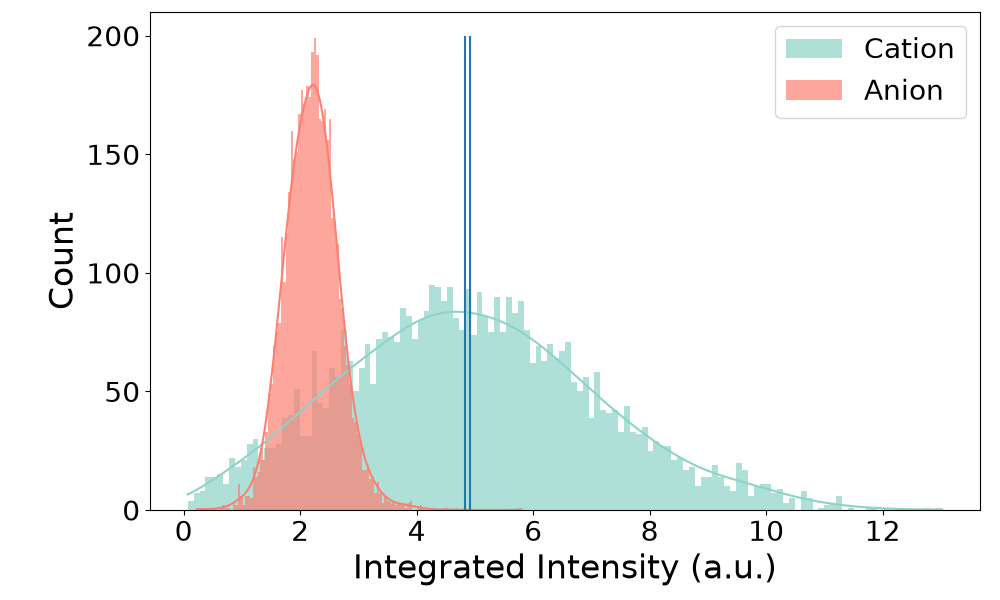

In [61]:
i_cation = np.array([sublattice_intensities[i][0][...,-1] for i in range(0,9)])
i_anion = np.array([sublattice_intensities[i][1][...,-1] for i in range(0,9)])
plt.figure(figsize = (10, 6))
plt.subplots_adjust(left=0.15, right=0.98, top=0.98, bottom=0.15)
sns.histplot(i_cation.flatten(), color="#8dd3c7", label="Cation", alpha=0.7, kde=True, bins = 128,edgecolor="none", kde_kws={"bw_adjust": 1.5})
sns.histplot(i_anion.flatten(), color="#fb8072", label="Anion", alpha=0.7, kde=True, bins =128,edgecolor="none", kde_kws={"bw_adjust": 1.5})
ax = plt.gca()
ax.set_xlabel("Integrated Intensity (a.u.)", fontsize = 24)
ax.set_ylabel("Count", fontsize = 24)
ax.tick_params(axis='both', which='major', labelsize=20)
plt.legend(fontsize = 20)

plt.vlines([i_cation.mean()], 0, 200)
plt.vlines([np.median(i_cation)], 0, 200)

#plt.savefig(os.path.join(work_dir, "integrated_intensity_histogram.svg"), dpi = 300, bbox_inches = 'tight', pad_inches = 0)

In [62]:
Cation_Li_sublattice = sublattice_intensities[0][0][sublattice_intensities[0][0][...,-1] < i_anion.mean() - i_anion.std()]
Cation_Li_sublattice 

array([[ 62.74426298,  97.42613268,   0.58961064],
       [176.85186969, 158.78114092,   0.96914101],
       [175.53039363,  26.89311372,   1.15620089],
       [328.82682544, 184.53883468,   1.64049256],
       [252.40047595, 278.83553734,   1.40960431],
       [271.9896807 , 303.32679047,   1.45565033],
       [ 81.38070841, 242.27005621,   1.12997699],
       [120.06918152, 266.0657001 ,   0.65551066],
       [176.90399848,  74.4528309 ,   1.68949389],
       [175.92908473, 241.93918514,   1.13593817],
       [272.12717606, 220.57299816,   0.61047626],
       [214.12287419, 159.19250635,   1.10510433],
       [119.10919852, 218.79787998,   0.48129401],
       [309.49316019, 243.02292781,   0.48763132],
       [ 43.82047882, 170.12357826,   0.90821159],
       [290.38957253,  99.50958269,   1.61239505],
       [ 24.24778913,  60.84099325,   1.46480215],
       [ 24.8820697 , 181.79890421,   0.63757551],
       [ 80.79614119, 157.61436998,   0.86671615],
       [253.59857688, 195.23746

In [63]:
Cation_Li_patches = []

for i in range(len(A_sublattices_by_slice)):
    cation_img = A_sublattices_by_slice[i].image
    cation_Li_site = sublattice_intensities[i][0][sublattice_intensities[i][0][...,-1] < 2]
    for j in range(len(cation_Li_site)):
        x, y = cation_Li_site[j][:2]
        if x-25 < 0 or y-20 < 0 or y+20 > cation_img.shape[0] or x+25 > cation_img.shape[1]:
            continue
        else:
            patch = cation_img[int(y-20):int(y+20), int(x-25):int(x+25)]
            Cation_Li_patches.append(patch)

In [64]:
Cation_Mn_patches = []

for i in range(len(A_sublattices_by_slice)):
    cation_img = A_sublattices_by_slice[i].image
    cation_Li_site = sublattice_intensities[i][0][sublattice_intensities[i][0][...,-1] > 8]
    for j in range(len(cation_Li_site)):
        x, y = cation_Li_site[j][:2]
        if x-25 < 0 or y-20 < 0 or y+20 > cation_img.shape[0] or x+25 > cation_img.shape[1]:
            continue
        else:
            patch = cation_img[int(y-20):int(y+20), int(x-25):int(x+25)]
            Cation_Mn_patches.append(patch)

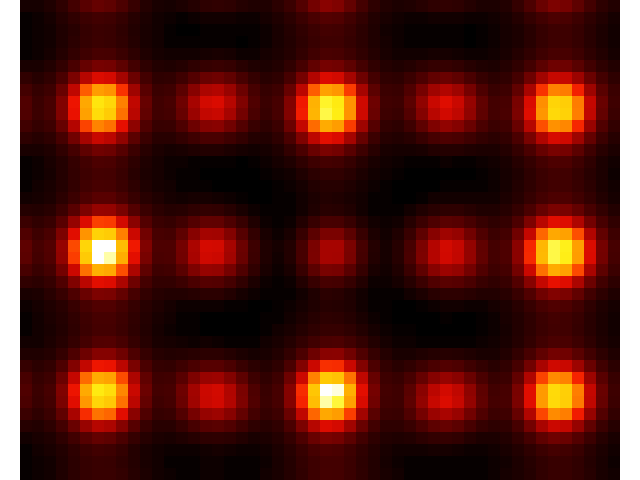

In [65]:
plt.figure()
plt.subplots_adjust(0, 0, 1, 1)
plt.imshow(np.mean(Cation_Li_patches,axis = 0), vmin = 0, vmax = 0.2, cmap = cc.cm.fire)
plt.axis('off')
plt.savefig(os.path.join(work_dir, 'Cation_Li_mean.png'), bbox_inches='tight', pad_inches=0)

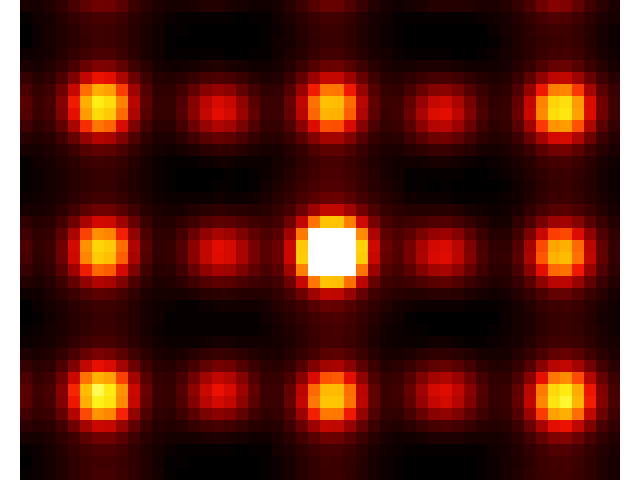

In [66]:
plt.figure()
plt.subplots_adjust(0, 0, 1, 1)
plt.imshow(np.mean(Cation_Mn_patches,axis = 0), vmin = 0, vmax = 0.2, cmap = cc.cm.fire)
plt.axis('off')
plt.savefig(os.path.join(work_dir, 'Cation_Mn_mean.png'), bbox_inches='tight', pad_inches=0)

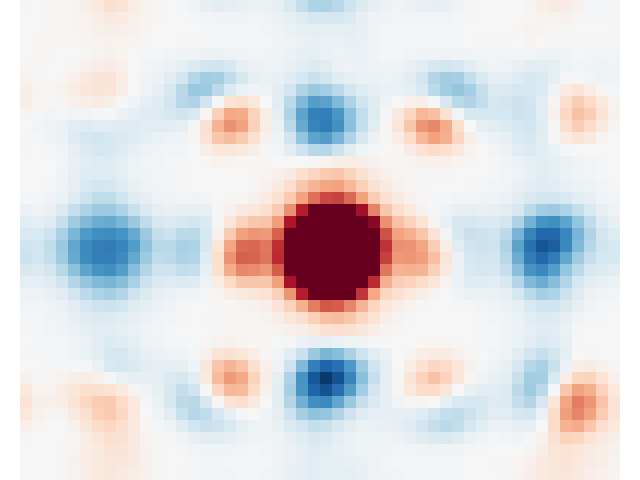

In [69]:
plt.figure()
plt.subplots_adjust(0, 0, 1, 1)
plt.imshow(np.mean(Cation_Mn_patches,axis = 0) - np.mean(Cation_Li_patches,axis = 0), vmin = -0.05, vmax = 0.05, cmap = "RdBu_r")
plt.axis('off')
plt.savefig(os.path.join(work_dir, 'Cation_Mn_minus_Li_mean.png'), bbox_inches='tight', pad_inches=0)

# Interpolate to grid and calculate ACF

In [ ]:
def image_autocorrelation_fft_3d(image):
    image = image - np.nanmean(image)
    z, m, n = image.shape
    full_shape = (2*z-1, 2*m - 1, 2*n - 1)

    img_fft = np.fft.fftn(image, s = full_shape)
    power_spectrum = np.abs(img_fft)**2
    autocorr_full = np.fft.ifftn(power_spectrum).real
    autocorr_full = np.fft.fftshift(autocorr_full)

    denom = autocorr_full.max()
    if np.isclose(denom,0):
        return autocorr_full

    return autocorr_full/denom


In [ ]:
def image_autocorrelation_fft_2d(image):
    image = image - np.nanmean(image)
    m, n = image.shape
    full_shape = (2*m - 1, 2*n - 1)

    img_fft = np.fft.fftn(image, s = full_shape)
    power_spectrum = np.abs(img_fft)**2
    autocorr_full = np.fft.ifftn(power_spectrum).real
    autocorr_full = np.fft.fftshift(autocorr_full)

    denom = autocorr_full.max()
    if np.isclose(denom,0):
        return autocorr_full

    return autocorr_full/denom

In [ ]:
from scipy.interpolate import griddata

In [ ]:
gridx, gridy = np.mgrid[0:img_stack.shape[1]:img_stack.shape[1]*1j, 0:img_stack.shape[2]:img_stack.shape[2]*1j]

In [ ]:
a = sublattice_intensities[0][0]

In [ ]:
a[...,0:2].shape

In [ ]:
a[...,1][::-1].shape

In [ ]:
a_interp = griddata(a[...,0:2], a[...,-1], (gridy, gridx), method = 'nearest',fill_value = 0)

In [ ]:
plt.figure()
#plt.imshow(img_stack[z_top], cmap = 'gray')
#plt.scatter(a[...,0], a[...,1], c = a[...,2], cmap = 'RdBu_r', alpha = 0.6)
plt.imshow(image_autocorrelation_fft_2d(a_interp[40:-40, 40:-40]), cmap = 'RdBu_r', vmin = -0.3, vmax = 0.3)

In [ ]:
sublattice_A_intensities_sorted = []
for i in range(len(sublattice_intensities)):
    a = np.asarray(sublattice_intensities[i][0])

    # Sort primarily by y (row) and secondarily by x (column).
    order = np.lexsort((a[:, 0], a[:, 1]))
    a_sorted = a[order]

    # Detect row boundaries from the gap between adjacent y coordinates.
    y_gaps = np.diff(a_sorted[:, 1])
    positive_gaps = y_gaps[y_gaps > 0]
    if positive_gaps.size == 0:
        raise ValueError("Could not detect multiple coordinate rows.")

    row_gap_threshold = 0.5 * (positive_gaps.min() + positive_gaps.max())
    row_breaks = np.flatnonzero(y_gaps > row_gap_threshold) + 1
    row_lengths = np.diff(np.r_[0, row_breaks, len(a_sorted)])

    if not np.all(row_lengths == row_lengths[0]):
        raise ValueError(f"Rows have unequal lengths: {row_lengths.tolist()}")

    r, c = len(row_lengths), int(row_lengths[0])
    a_row_column = a_sorted.reshape(c,r, 3)
    sublattice_A_intensities_sorted.append(a_row_column)

sublattice_A_intensities_sorted = np.array(sublattice_A_intensities_sorted)
sublattice_A_intensities_sorted[...,-1].shape
#a_row_column.shape

In [ ]:
a_row_column[0,:,0]

In [ ]:
_,  axs = plt.subplots(1, 2)
axs[0].imshow(img_stack[z_top], cmap = 'gray')
#axs[0].scatter(a[...,0], a[...,1], c = a[...,2], cmap = 'RdBu_r', alpha = 0.6)
axs[0].imshow(a_interp, cmap = 'RdBu_r', alpha = 0.9, 
              vmin = a_row_column[...,-1].min(), vmax = a_row_column[...,-1].max())

#axs[1].imshow(img_stack[z_top], cmap = 'gray')
#axs[1].scatter(a_row_column[:,:,0], a_row_column[:,:,1], c = a_row_column[:, :, 2], cmap = "RdBu_r", vmin = a_row_column[...,-1].min(), vmax = a_row_column[...,-1].max())
axs[1].imshow(a_row_column[...,2], aspect = 28/19, cmap = 'RdBu_r',vmin = a_row_column[...,-1].min(), vmax = a_row_column[...,-1].max())

In [ ]:
sublattice_A_intensities_sorted_autocorr = [image_autocorrelation_fft_2d(a_row_column[...,2]) for a_row_column in sublattice_A_intensities_sorted]

In [ ]:
sublattice_A_intensities_sorted_autocorr = image_autocorrelation_fft_3d(sublattice_A_intensities_sorted[...,2])
sublattice_A_intensities_sorted_autocorr .shape

In [ ]:
saplot.PlotImage(sublattice_A_intensities_sorted_autocorr[0],dr = 1, cmap = 'RdBu_r')
plt.gca().set_aspect(28/19)


In [ ]:
cation_sublattice_intensities = [sublattice_intensities[i][0] for i in range(z_bottom-z_top)]
anion_sublattice_intensities = [sublattice_intensities[i][1] for i in range(z_bottom-z_top)]

In [ ]:
cation_sublattice_intensities = np.array(cation_sublattice_intensities)
anion_sublattice_intensities = np.array(anion_sublattice_intensities)

In [ ]:
from scipy.signal import correlate

In [ ]:
plt.figure()

ac_list = []
for i in range(cation_sublattice_intensities.shape[1]):
    ac = correlate(cation_sublattice_intensities[:,i,2],cation_sublattice_intensities[:,i,2], mode = 'full')
    ac_list.append(ac/ac.max())
    plt.plot(ac/ac.max(), color = 'gray', alpha = 0.5)

plt.plot(np.mean(ac_list,0), color = "#8dd3c7")
plt.hlines(0, 0,18)
#plt.plot(cation_sublattice_intensities[...,2].mean(1))

In [ ]:
plt.figure()

ac_list = []
for i in range(anion_sublattice_intensities.shape[1]):
    ac = correlate(anion_sublattice_intensities[:,i,2],anion_sublattice_intensities[:,i,2], mode = 'full')
    ac_list.append(ac/ac.max())
    plt.plot(ac/ac.max(), color = 'gray', alpha = 0.5)

plt.plot(np.mean(ac_list,0), color = "#fb8072")
plt.hlines(0, 0,18)
#plt.plot(cation_sublattice_intensities[...,2].mean(1))

In [ ]:
cation_intensity_interp = []
for i in range(9):
    intensity_interp = griddata(cation_sublattice_intensities[i][...,0:2][:,::-1], cation_sublattice_intensities[i][...,2], (gridx, gridy), method = 'nearest', fill_value = 0)
    cation_intensity_interp.append(intensity_interp)
cation_intensity_interp = np.array(cation_intensity_interp)

In [ ]:
autocorr_cation_intensity = image_autocorrelation_fft(cation_intensity_interp[:, 20:-20, 20:-20])

In [ ]:
autocorr_cation_intensity.shape

In [ ]:
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

for i, layer_positions in enumerate(cation_sublattice_intensities):
    x = layer_positions[:, 0]
    y = layer_positions[:, 1]
    z = np.full_like(x, i)
    intensities = layer_positions[:, 2]
    sc = ax.scatter(x, y, z, c=intensities, cmap='inferno', s=20)

ax.set_xlabel('X (pixels)')
ax.set_ylabel('Y (pixels)')
ax.set_zlabel('Layer index (z)')
fig.colorbar(sc, ax=ax, label='Integrated Intensity (a.u.)', shrink=0.6)
ax.set_title('Cation Sublattice Intensity by Layer')

plt.tight_layout()
plt.show()

In [ ]:
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

vmin, vmax = cation_intensity_interp.min(), cation_intensity_interp.max()
levels = np.linspace(vmin, vmax, 51)

for i, layer in enumerate(cation_intensity_interp):
    cs = ax.contourf(gridx, gridy, layer, levels=levels, zdir='z', offset=i, cmap='inferno')

ax.set_zlim(0, cation_intensity_interp.shape[0] - 1)
ax.set_xlabel('X (pixels)')
ax.set_ylabel('Y (pixels)')
ax.set_zlabel('Layer index (z)')
fig.colorbar(cs, ax=ax, label='Interpolated Intensity (a.u.)', shrink=0.6)
ax.set_title('Interpolated Cation Sublattice Intensity by Layer')

plt.tight_layout()
plt.show()

In [ ]:
17//2

In [ ]:
lattice_y = np.arange(-10, 10)*12 + autocorr_cation_intensity.shape[1]//2
lattice_x = np.arange(-10, 10)*19 + autocorr_cation_intensity.shape[1]//2

lattice_y 

In [ ]:
plt.figure(figsize = (10, 10))
plt.subplots_adjust(0.2, 0.2, 0.8, 0.8)
plt.imshow(autocorr_cation_intensity[8], vmin = -0.1, vmax = 0.1, cmap = cc.cm.bkr)
plt.vlines(lattice_x, 0, autocorr_cation_intensity.shape[1], color = 'w', lw = 0.5)
plt.hlines(lattice_y, 0, autocorr_cation_intensity.shape[1], color = 'w', lw = 0.5)


plt.xticks(lattice_x, [str(i) for i in range(-10, 10)], fontsize = 32)
plt.yticks(lattice_y, [str(i) for i in range(-10, 10)], fontsize = 32)

plt.xlim((autocorr_cation_intensity.shape[1]//2-50, autocorr_cation_intensity.shape[1]//2+50))
plt.ylim(autocorr_cation_intensity.shape[1]//2-50, autocorr_cation_intensity.shape[1]//2+50)

plt.savefig(os.path.join(work_dir, "autocorr_cation_intensity.svg"), dpi = 300, bbox_inches = 'tight', pad_inches = 0)

#plt.plot(autocorr_cation_intensity[8, autocorr_cation_intensity.shape[1]//2, :]+autocorr_cation_intensity.shape[1]//2, color = 'k', lw = 2)


In [ ]:
plt.figure(figsize = (10, 10))
plt.subplots_adjust(0, 0, 1, 1)
plt.imshow(autocorr_cation_intensity[:, :,637//2], vmin = -0.2, vmax = 0.2, cmap = cc.cm.coolwarm, aspect = dz/dx/10)
#plt.vlines(lattice_x, 0, autocorr_cation_intensity.shape[1], color = 'k', lw = 0.5)
#plt.hlines(lattice_y, 0, autocorr_cation_intensity.shape[1], color = 'k', lw = 0.5)


#plt.plot(autocorr_cation_intensity[8, autocorr_cation_intensity.shape[1]//2, :]+autocorr_cation_intensity.shape[1]//2, color = 'k', lw = 2)


In [ ]:
plt.figure()
x = np.arange(len(autocorr_cation_intensity[8, autocorr_cation_intensity.shape[1]//2, autocorr_cation_intensity.shape[2]//2:]))*dx
x -= x[-1]/2
plt.plot(x, autocorr_cation_intensity[8, autocorr_cation_intensity.shape[1]//2, autocorr_cation_intensity.shape[2]//2:], color = 'k', lw = 2)
plt.vlines(x[::19], -1, 1, color = 'r', lw = 1, ls = '--')

In [ ]:
plt.figure()
y = np.arange(len(autocorr_cation_intensity[8, :, autocorr_cation_intensity.shape[1]//2]))*dx
y -= y[-1]/2
plt.plot(y, autocorr_cation_intensity[8, :, autocorr_cation_intensity.shape[1]//2], color = 'k', lw = 2)
plt.vlines(y[len(y)//2::12], -1, 1, color = 'r', lw = 1, ls = '--')

In [ ]:
plt.figure()
z = np.arange(len(autocorr_cation_intensity[:, autocorr_cation_intensity.shape[1]//2, autocorr_cation_intensity.shape[2]//2]))*dx
z -= z[-1]/2
plt.plot(z, autocorr_cation_intensity[:, autocorr_cation_intensity.shape[1]//2, autocorr_cation_intensity.shape[2]//2], color = 'k', lw = 2)
#plt.vlines(x[len(x)//2::19], -1, 1, color = 'r', lw = 1, ls = '--')

In [ ]:
plt.figure()
plt.imshow(cation_intensity_interp, cmap = 'RdBu_r', vmin = 0, vmax = 10)

In [ ]:
cation_sublattice_intensities[0][...,0:2],grid.shape

In [ ]:
plt.figure()
plt.imshow(cation_sublattice.image, cmap='inferno',vmin = 0,vmax = np.pi/16)
plt.imshow(cation_intensity_interp, cmap = 'RdBu_r', vmin = 0, vmax = 10, alpha = 0.5)
plt.colorbar()

# Find nearest antion around cation

In [ ]:
A_sub = A_sublattices_by_slice[0]
B_sub = B_sublattices_by_slice[0]

In [ ]:
from scipy.spatial import cKDTree

A_positions = np.asarray(A_sub.atom_positions)
B_positions = np.asarray(B_sub.atom_positions)

if B_positions.shape[0] < 6:
    raise ValueError("B_sub must contain at least four atom positions.")

B_tree = cKDTree(B_positions)
A_to_B_distances, A_to_B_indices = B_tree.query(A_positions, k=6)
A_to_B_positions = B_positions[A_to_B_indices]

# Shapes: (number of A sites, 4), (number of A sites, 4), (number of A sites, 4, 2)
A_to_B_distances, A_to_B_indices, A_to_B_positions

In [ ]:
ind = np.random.randint(0, len(A_to_B_indices))
B_pos_neighbor = B_positions[A_to_B_indices[ind]]
order = np.lexsort((B_pos_neighbor[:, 0], B_pos_neighbor [:, 1]))
B_pos_neighbor_sorted = B_pos_neighbor[order]
plt.figure()
plt.imshow(img_stack[z_top])
plt.scatter(A_positions[ind][0], A_positions[ind][1],c = 'r')
plt.scatter(B_pos_neighbor_sorted[:,0], B_pos_neighbor_sorted[:,1], c = np.arange(6), cmap = 'RdBu_r')

In [ ]:
features = []
for i in range(len(A_to_B_indices)):
    cation_pos = A_positions[i]
    anion_poses = B_positions[A_to_B_indices[i]]
    order = np.lexsort((anion_poses[:,0], anion_poses[:,1]))
    anion_poses_sorted = anion_poses[order]
    relative_vec = anion_poses - cation_pos
    features.append(relative_vec)
features = np.asarray(features)
features.shape

In [ ]:
X = features.reshape(features.shape[0], -1)
pca = PCA()
pca.fit(X)

explained_var = pca.explained_variance_ratio_
cum_explained_var = np.cumsum(explained_var)

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 6))
comps = np.arange(1, len(explained_var) + 1)

ax1.bar(comps, explained_var, alpha=0.6, color="#8dd3c7", label="Explained variance")
ax1.set_xlabel("Principal Component", fontsize=16)
ax1.set_ylabel("Explained Variance Ratio", fontsize=16)
ax1.tick_params(axis='both', which='major', labelsize=12)

ax2 = ax1.twinx()
ax2.plot(comps, cum_explained_var, color="#fb8072", marker='o', markersize=3, label="Cumulative")
ax2.set_ylabel("Cumulative Explained Variance", fontsize=16)
ax2.set_ylim(0, 1.05)
ax2.tick_params(axis='both', which='major', labelsize=12)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=12, loc='center right')

plt.title("PCA Explained Variance on delta_patches", fontsize=16)
fig.tight_layout()
#
#plt.savefig(os.path.join(work_dir, "pca_explained_variance.svg"), dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
from sklearn.decomposition import PCA

if features.ndim != 3 or features.shape[1:] != (6, 2):
    raise ValueError(f"Expected features with shape (n_cations, 6, 2), got {features.shape}")

feature_matrix = features.reshape(features.shape[0], -1)
neighbor_pca = PCA()
feature_scores = neighbor_pca.fit_transform(feature_matrix)

principal_components = neighbor_pca.components_.reshape(-1, 6, 2)
explained_variance_ratio = neighbor_pca.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

pca_results = {
    "feature_matrix": feature_matrix,
    "scores": feature_scores,
    "components": principal_components,
    "explained_variance_ratio": explained_variance_ratio,
    "cumulative_explained_variance": cumulative_explained_variance,
}

print("Feature matrix:", feature_matrix.shape)
print("Components:", principal_components.shape)
print("Explained variance ratio:", explained_variance_ratio)
print("Cumulative explained variance:", cumulative_explained_variance)

In [ ]:
plt.figure()
plt.plot(explained_variance_ratio)
plt.plot(cumulative_explained_variance)

In [ ]:
n_pc = 8
components_img = neighbor_pca.components_[0:8].reshape(n_pc, 6, 2)
components_img

In [ ]:
A_sub.atom_positions

# PCA Analysis of structure motifs

In [ ]:
img = img_stack[z_top]

In [ ]:
plt.figure()
plt.imshow(img, vmax = np.pi/16)

In [ ]:
patch_window = [36, 50]

In [ ]:
cation_pos = A_sublattices_by_slice[0].atom_positions

In [ ]:
patches = []
for pos in cation_pos:
    x, y = pos[::-1]
    x, y = int(x), int(y)
    patch = img[x-patch_window[0]//2:x+patch_window[0]//2, y-patch_window[1]//2:y+patch_window[1]//2]
    if patch.shape[0] == patch_window[0] and patch.shape[1] == patch_window[1]:
        patches.append(patch)
patches = np.array(patches)
patches

In [ ]:
#np.save(os.path.join(work_dir, "patches.npy"), patches)

In [ ]:
plt.figure()
plt.imshow(patches.mean(0), cmap='inferno')

In [ ]:
delta_patches = patches - patches.mean(0)

In [ ]:
plt.figure()
plt.imshow(delta_patches[0], cmap='RdBu_r', vmin = -0.1, vmax = 0.1)

In [ ]:
from sklearn.decomposition import PCA



In [ ]:
delta_patches.shape

In [ ]:
X = delta_patches.reshape((delta_patches.shape[0], -1))
pca = PCA()
pca.fit(X)

explained_var = pca.explained_variance_ratio_
cum_explained_var = np.cumsum(explained_var)

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 6))
comps = np.arange(1, len(explained_var) + 1)

ax1.bar(comps, explained_var, alpha=0.6, color="#8dd3c7", label="Explained variance")
ax1.set_xlabel("Principal Component", fontsize=16)
ax1.set_ylabel("Explained Variance Ratio", fontsize=16)
ax1.tick_params(axis='both', which='major', labelsize=12)

ax2 = ax1.twinx()
ax2.plot(comps, cum_explained_var, color="#fb8072", marker='o', markersize=3, label="Cumulative")
ax2.set_ylabel("Cumulative Explained Variance", fontsize=16)
ax2.set_ylim(0, 1.05)
ax2.tick_params(axis='both', which='major', labelsize=12)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=12, loc='center right')

plt.title("PCA Explained Variance on delta_patches", fontsize=16)
fig.tight_layout()
#plt.savefig(os.path.join(work_dir, "pca_explained_variance.svg"), dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
n_pc = 12
components_img = pca.components_[0:12].reshape(n_pc, patch_window[0], patch_window[1])

fig, axes = plt.subplots(4, n_pc//4, figsize=(5 * n_pc//4, 5))
for i, ax in enumerate(axes.flatten()):
    vmax = np.abs(components_img[i]).max()
    im = ax.imshow(components_img[i], cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.set_title(f"PC {i+1} ({explained_var[i]*100:.1f}%)", fontsize=16)
    ax.axis('off')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.tight_layout()
#plt.savefig(os.path.join(work_dir, "pca_first_3_components.svg"), dpi=300, bbox_inches='tight')
plt.show()